In [1]:
import pandas as pd  
 
data = pd.read_csv('../data/adult.csv')
import pandas as pd   
 
numerical_attributes = data.select_dtypes(include=['int64', 'float64']).columns.tolist()  
 
print(numerical_attributes)

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


In [2]:
unique_counts = data.nunique()  
 
unique_counts_df = pd.DataFrame(unique_counts).reset_index()  
unique_counts_df.columns = ['Attribute', 'Unique Values Count']  
 
print(unique_counts_df)

         Attribute  Unique Values Count
0              age                   73
1        workclass                    9
2           fnlwgt                21648
3        education                   16
4    education-num                   16
5   marital-status                    7
6       occupation                   15
7     relationship                    6
8             race                    5
9              sex                    2
10    capital-gain                  119
11    capital-loss                   92
12  hours-per-week                   94
13  native-country                   42
14          income                    2


In [3]:

unique_workclass_values = data['workclass'].unique()  
 
print(unique_workclass_values)

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


In [9]:
data.fillna('?', inplace=True)  


missing_values_count = data.apply(lambda x: (x == '?').sum())  


missing_values_count = missing_values_count[missing_values_count > 0]  


missing_values_df = missing_values_count.reset_index()  
missing_values_df.columns = ['Attribute', 'Missing Values Count']  
 
print(missing_values_df)

        Attribute  Missing Values Count
0       workclass                  1836
1      occupation                  1843
2  native-country                   583


In [28]:
total_individuals = len(data)  

us_natives_count = data[data['native-country'].str.strip() == 'United-States'].shape[0]  

percentage_us_natives = (us_natives_count / total_individuals) * 100  
 
print(f"Percentage of individuals who are natively from the United States: {percentage_us_natives:.3f}%")

Percentage of individuals who are natively from the United States: 89.586%


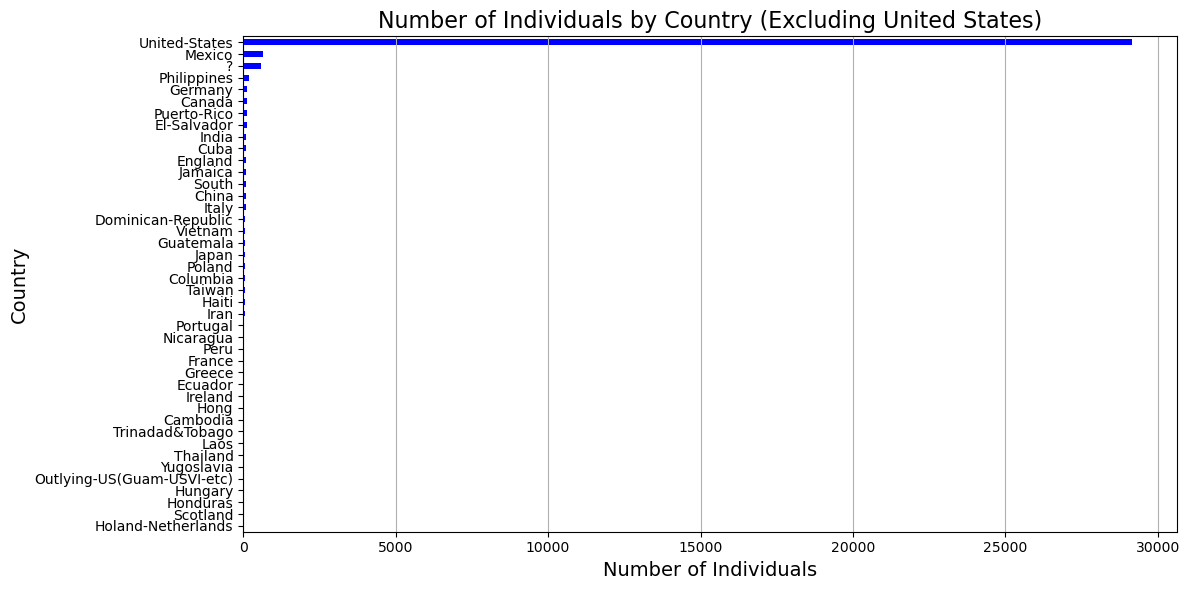

In [26]:

import matplotlib.pyplot as plt  


# Filter out individuals from the United States  
filtered_data = data[data['native-country'] != 'United States']  

# Count the number of individuals from each country  
country_counts = filtered_data['native-country'].value_counts()  

# Sort countries by number of individuals  
sorted_country_counts = country_counts.sort_values()  

# Create a bar plot  
plt.figure(figsize=(12, 6))  
sorted_country_counts.plot(kind='barh', color='blue')  

# Add title and labels  
plt.title('Number of Individuals by Country (Excluding United States)', fontsize=16)  
plt.xlabel('Number of Individuals', fontsize=14)  
plt.ylabel('Country', fontsize=14)  

# Show grid for better readability  
plt.grid(axis='x')  

# Display the plot  
plt.tight_layout()  
plt.show()